In [1]:
import numpy as np
from core import Simulation
import matplotlib.pyplot as plt
import pandas as pd
import eurostat
from data_scraper import *
from plotter import *
import geopandas as gpd
import imageio
import os
from scipy import stats


In [2]:
# Intrested in the year
Y = 2022
filename="connectivity_"+str(Y)+".csv"

# Fetch transportation data
df_connectivity = fetch_eu_air_traffic(year=Y, filename=filename, check=filename)

# Fetch population data
df_pop = fetch_eu_populations(year=Y)
df_pop = df_pop.set_index("Country_Code")

+ Fetching Eurostat Air Traffic Data...
Loaded succesfully!
+ Fetching Eurostat Population Data...
   -> Successfully loaded populations for 50 entities.


In [3]:
# Filter out cities with air traffic and Nan pop values
df_pop = df_pop.dropna()
valid_countries = df_pop.index.tolist()
valid_nodes = [node for node in df_connectivity.index if node in valid_countries]
df_connectivity = df_connectivity.loc[valid_nodes, valid_nodes]
df_pop = df_pop.loc[df_connectivity.index.to_list()]

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
population = df_pop.to_numpy().flatten().copy()

# Generate connectivity matrix
C = df_connectivity.to_numpy().copy()

# Adding sum of rows to diag
C += (np.diag(C.sum(axis=1)) * np.diag(population)) ** 0.65

# Weighting the columns by populations
#C = C * population[:, np.newaxis]

treshold = 0.0005


# Normalizing rows, asymmetric matrix; zero diagonal; rows sum to 1
C = C / np.sum(C, axis=1, keepdims=True)

C[C < treshold] = 0

C = C / np.sum(C, axis=1, keepdims=True)

In [5]:
pd.DataFrame(C)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33
0,0.982608,0.000592,0.000000,0.000851,0.000000,0.000000,0.004587,0.000000,0.000000,0.001534,0.002696,0.000000,0.001177,0.000000,0.000000,0.000000,0.000000,0.002149,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001048,0.000000,0.000564,0.000000,0.000679,0.000000,0.000000,0.000000,0.000000,0.001513
1,0.000512,0.984565,0.000000,0.000608,0.000000,0.000000,0.001118,0.000000,0.000000,0.001036,0.005024,0.000000,0.001584,0.000000,0.000000,0.000000,0.000000,0.002787,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001274,0.000561,0.000000,0.000000,0.000000,0.000000,0.000932
2,0.001265,0.000523,0.984700,0.000000,0.000000,0.000876,0.004670,0.000000,0.000000,0.000000,0.001259,0.000000,0.000753,0.000000,0.000000,0.000000,0.000000,0.002039,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000956,0.000000,0.001758,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001201
3,0.000685,0.000576,0.000000,0.978398,0.000000,0.000000,0.003052,0.000545,0.000000,0.001384,0.004824,0.000000,0.002878,0.000000,0.000000,0.000000,0.000000,0.002201,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001245,0.000000,0.000000,0.002250,0.000000,0.000000,0.000000,0.000000,0.000000,0.001962
4,0.003788,0.000627,0.001495,0.001652,0.943420,0.000745,0.006078,0.001845,0.000000,0.017563,0.000000,0.000661,0.001660,0.000000,0.002197,0.000000,0.000000,0.002253,0.000612,0.000000,0.000602,0.000000,0.000000,0.000797,0.001302,0.000990,0.005290,0.000000,0.002017,0.001077,0.002434,0.000000,0.000894,0.000000
5,0.000000,0.000000,0.000559,0.000000,0.000000,0.989524,0.001125,0.000000,0.000000,0.001464,0.001750,0.000000,0.001322,0.000000,0.000000,0.000000,0.000000,0.001980,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000908,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001366
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.994707,0.000000,0.000000,0.000769,0.002101,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000870,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001553
7,0.000602,0.000536,0.000000,0.000792,0.000000,0.000000,0.002233,0.973839,0.000000,0.001608,0.004350,0.000728,0.001852,0.000000,0.000000,0.000000,0.000747,0.001924,0.000503,0.000000,0.000000,0.000000,0.000000,0.000000,0.002173,0.002993,0.001197,0.000562,0.000000,0.000000,0.001628,0.000000,0.000000,0.001733
8,0.000765,0.000538,0.000000,0.000597,0.000000,0.000000,0.005392,0.000989,0.965514,0.000751,0.001115,0.003757,0.001248,0.000000,0.000000,0.000000,0.000000,0.003863,0.000854,0.000000,0.003438,0.000000,0.000000,0.000000,0.001112,0.001060,0.002223,0.000000,0.000000,0.000000,0.003107,0.000000,0.000000,0.003677
9,0.000972,0.000898,0.000000,0.000967,0.001138,0.000565,0.006060,0.000764,0.000000,0.978159,0.000564,0.000000,0.002351,0.000000,0.000000,0.000000,0.000000,0.002785,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001618,0.000000,0.001383,0.000000,0.000506,0.000000,0.000676,0.000000,0.000000,0.000594


In [6]:
# Seed 0.1% infection in a moderately populated country; rest fully susceptible

mode = np.median(population)

def find_nearest_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

mode_idx = find_nearest_idx(population, mode)

S0 = population
S0[mode_idx] = 0.999 * mode

I0 = np.zeros_like(population)
I0[mode_idx] = 0.001 * mode

R0 = np.zeros_like(population)
init_state = np.concatenate([S0, I0, R0])

beta = 0.1
mu = 0.03
t_end = 365 * 2

sim = Simulation(
    populations=population,
    init_state=init_state,
    connection_matrix=C,
    infection_rate=beta,       
    recovery_rate=mu,        
)
sim.solve_system(t_end=t_end) 
t, S, I, R = sim.get_results()

print("Location :", valid_countries[mode_idx], "; Population :", mode)



Location : AZ ; Population : 6639794.5


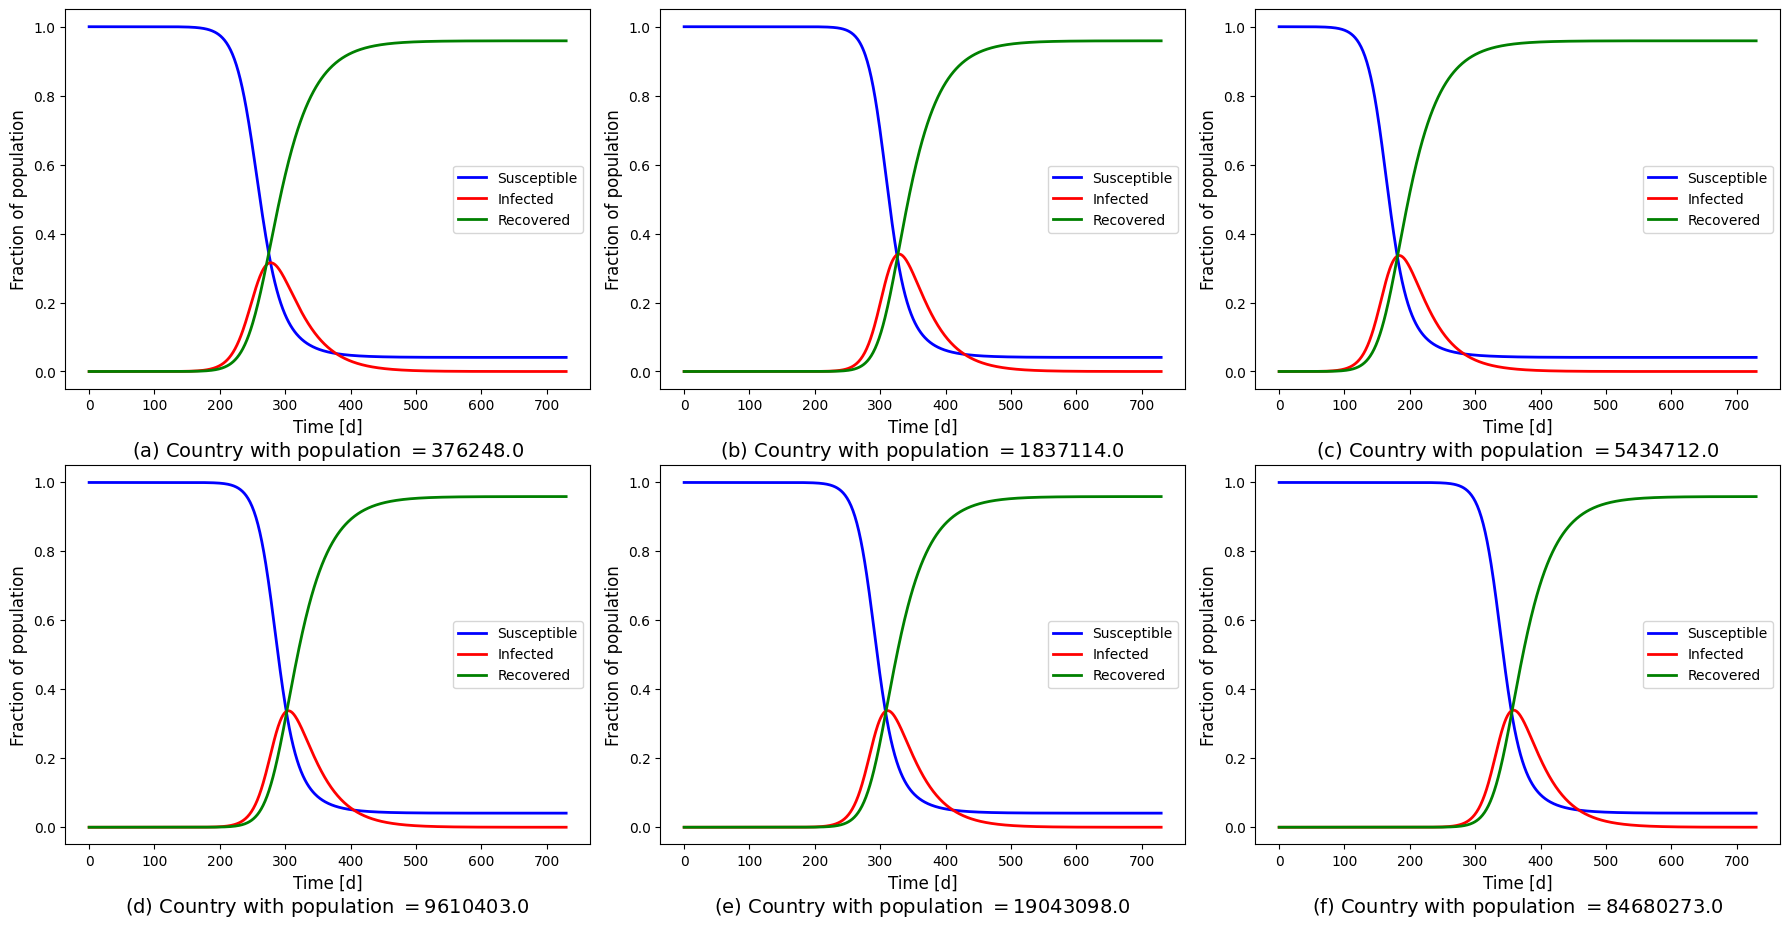

In [7]:
social_connectivity_comp(population, init_state, C,
                          t_end=t_end, infection_rate=beta, recovery_rate=mu)

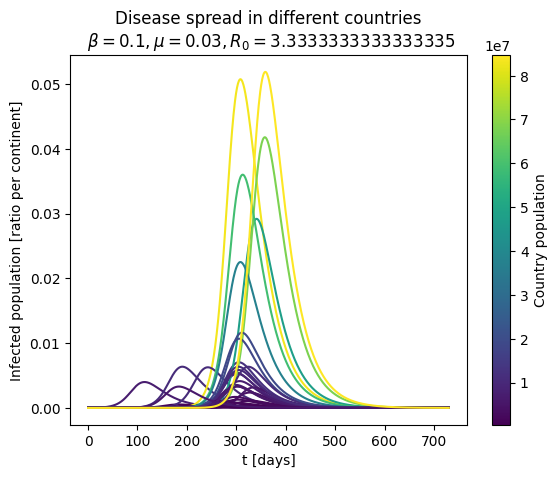

In [8]:
simple_plot(population, init_state, C,
                          t_end=t_end, infection_rate=beta, recovery_rate=mu)

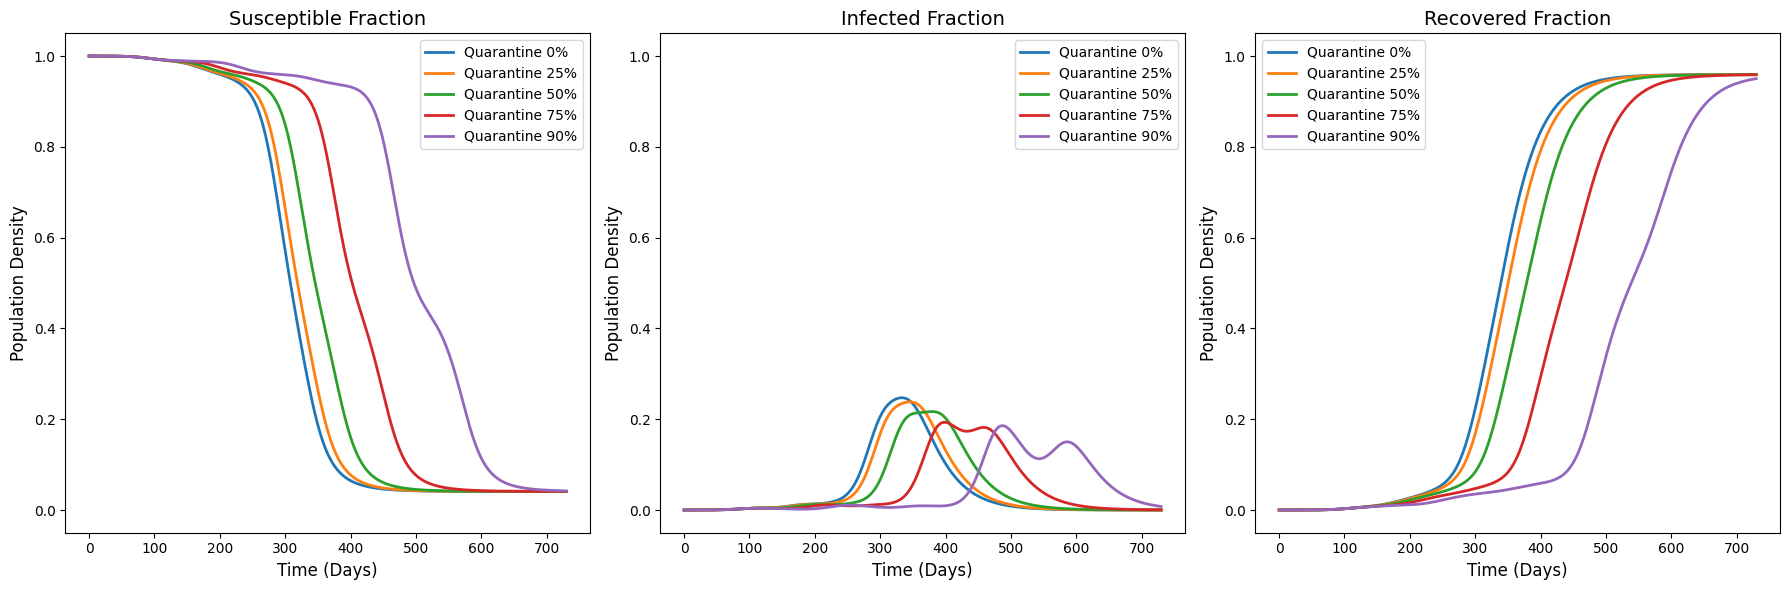

In [9]:
quarantine_plotter_2d(population, init_state, C,
                        infection_rate=beta, recovery_rate=mu, t_end=t_end)

Running 25 simulations. Please wait...


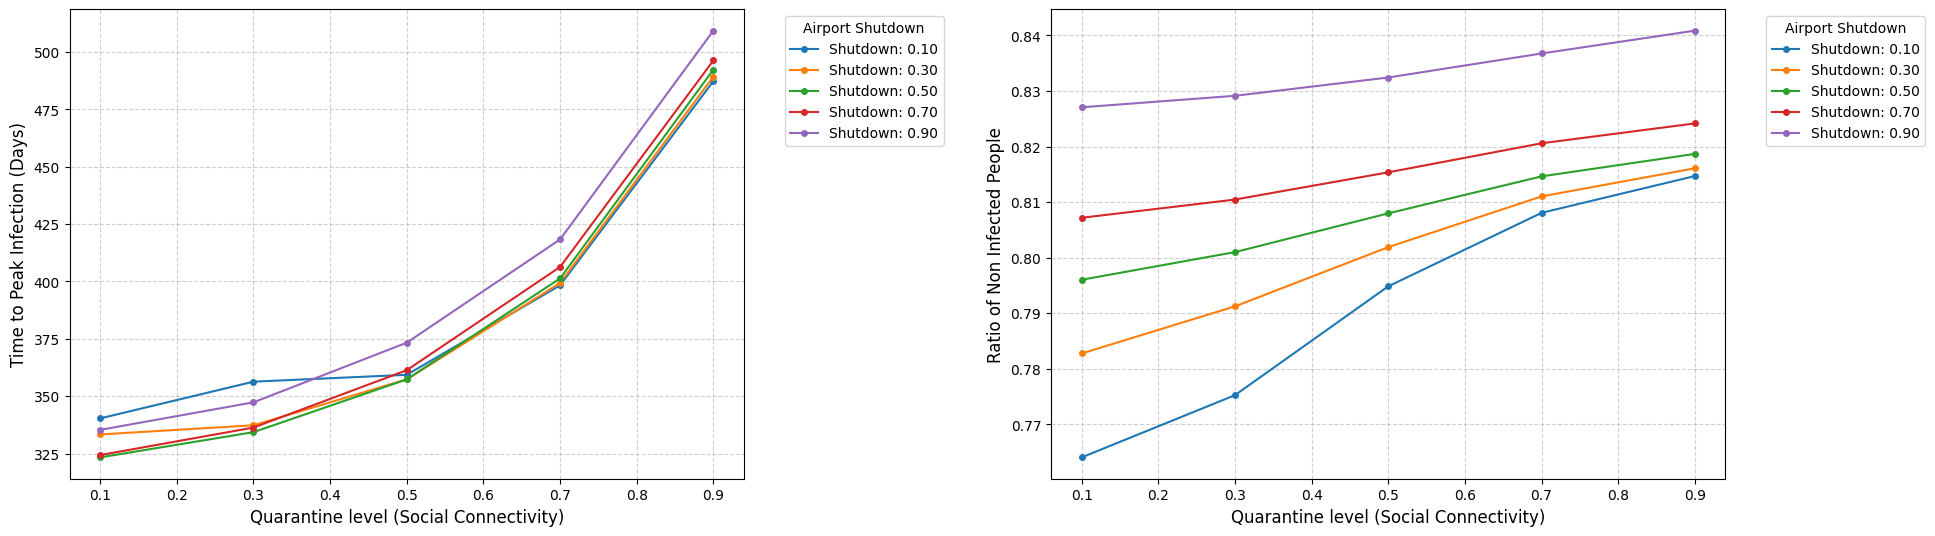

In [10]:
local_vs_global_quarantine_2d(population, init_state, C, beta, mu, 
                               t_end=t_end, 
                               quarantine_range=np.linspace(0.1, 0.9, 5),
                               top_nodes_under_quarantine=5,
                               social_connectivity_range=np.linspace(0.1, 0.9, 5))

Location : HR ; Population : 375871.752


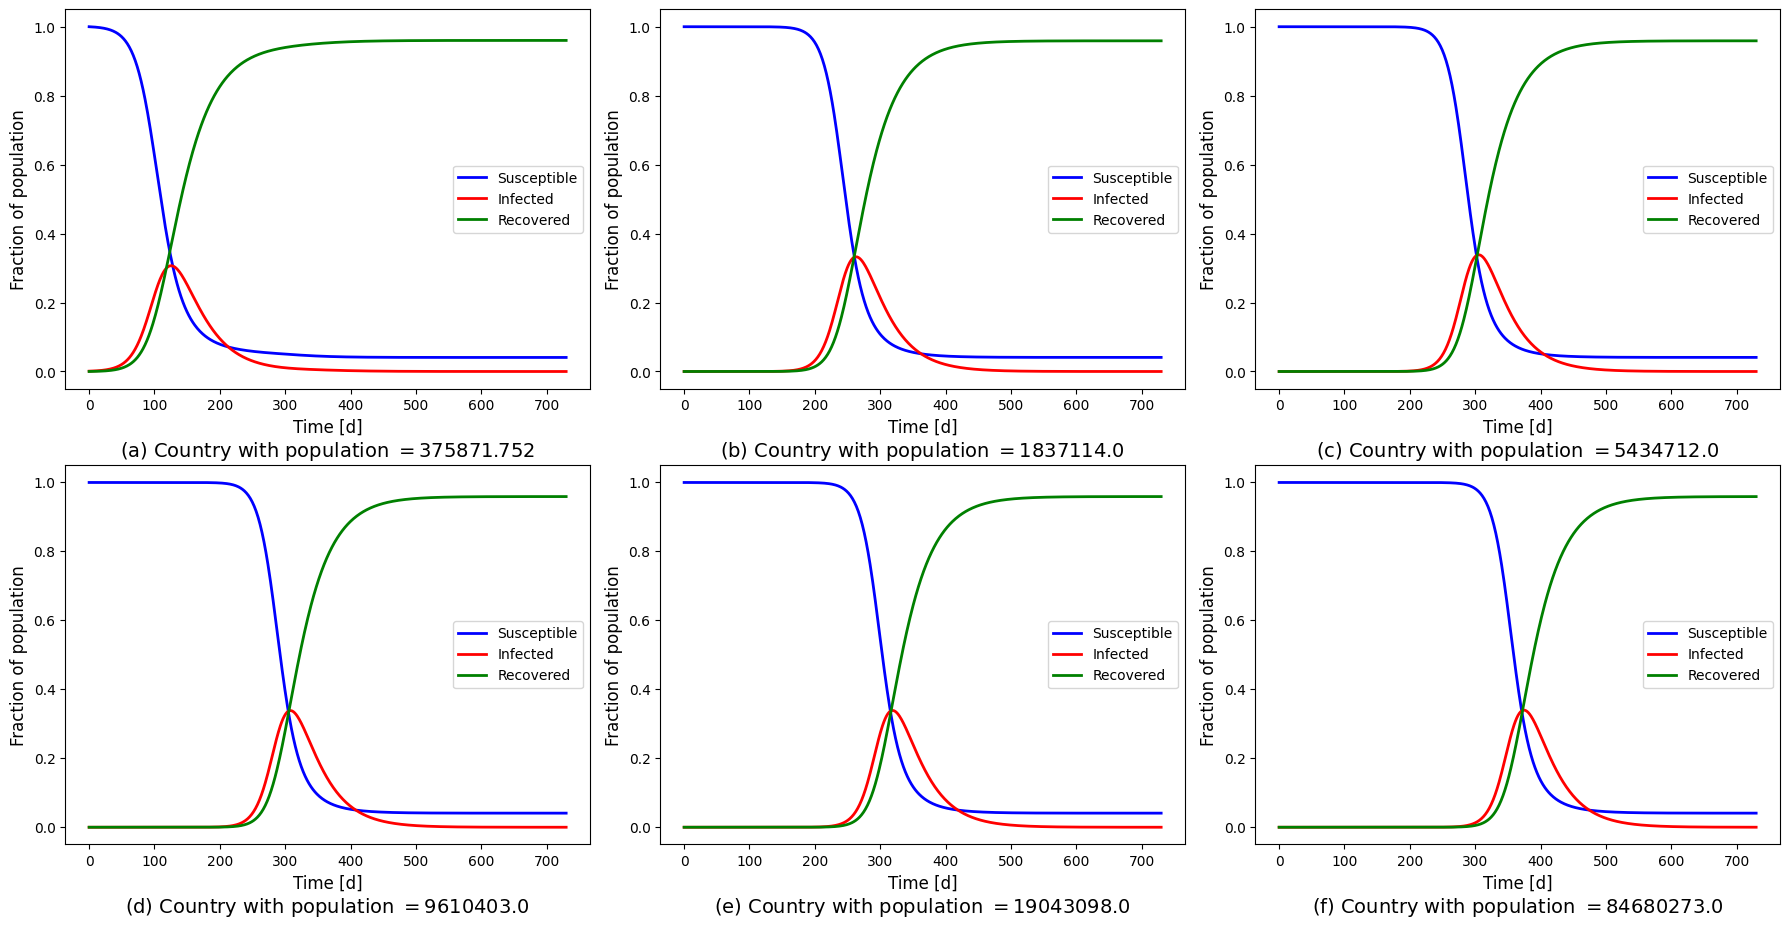

In [11]:
# Seed 0.1% infection in the lowest populated country; rest fully susceptible
S0 = population
S0[np.argmin(population)] = 0.999 * np.min(population)

I0 = np.zeros_like(population)
I0[np.argmin(population)] = 0.001 * np.min(population)

print("Location :", valid_countries[np.argmin(population)], "; Population :", np.min(population))
init_state = np.concatenate([S0, I0, R0])

social_connectivity_comp(population, init_state, C,
                          t_end=t_end, infection_rate=beta, recovery_rate=mu)

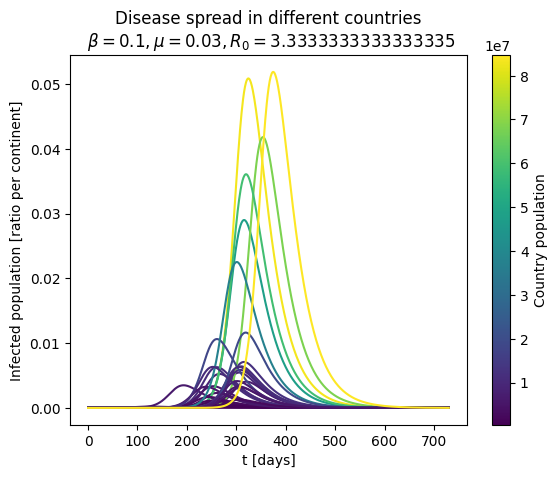

In [12]:
simple_plot(population, init_state, C,
                          t_end=t_end, infection_rate=beta, recovery_rate=mu)

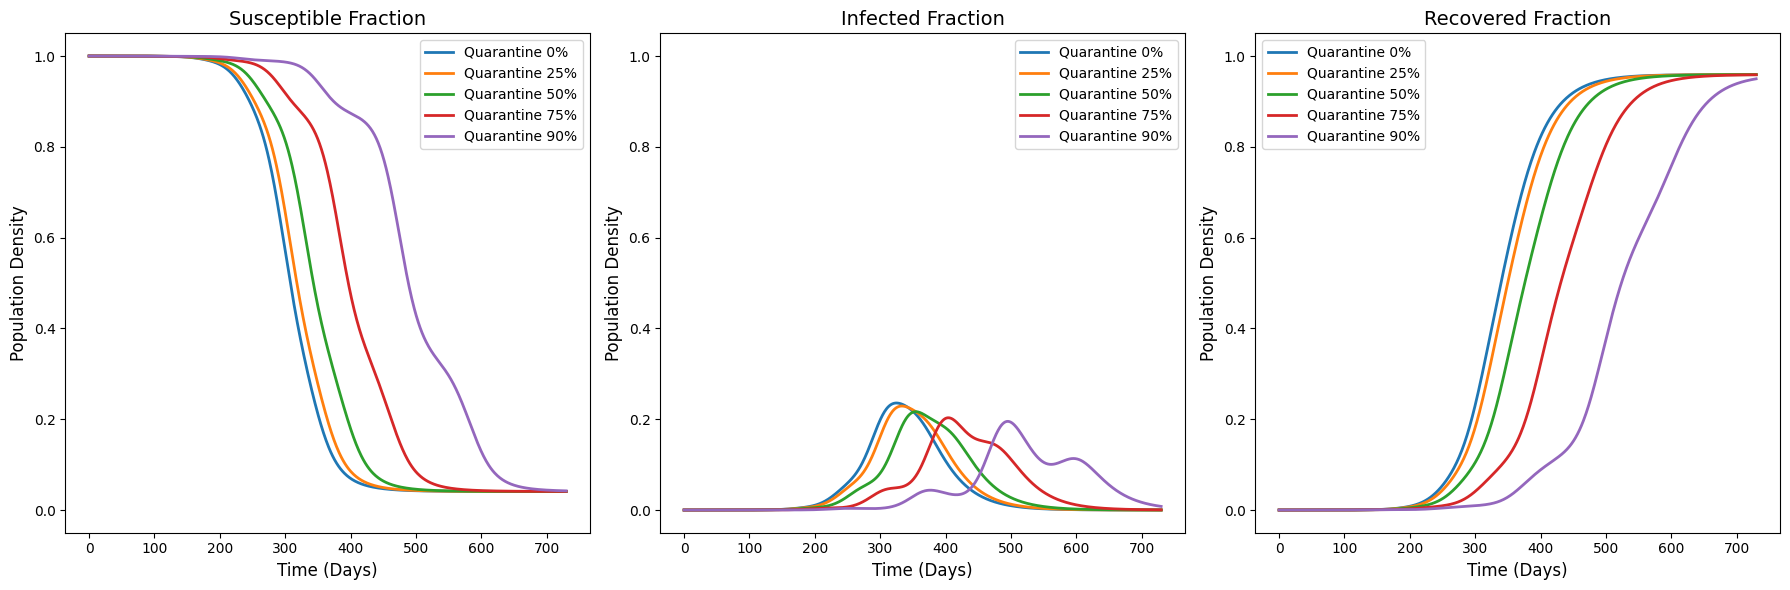

In [13]:
quarantine_plotter_2d(population, init_state, C,
                        infection_rate=beta, recovery_rate=mu, t_end=t_end)

Running 25 simulations. Please wait...


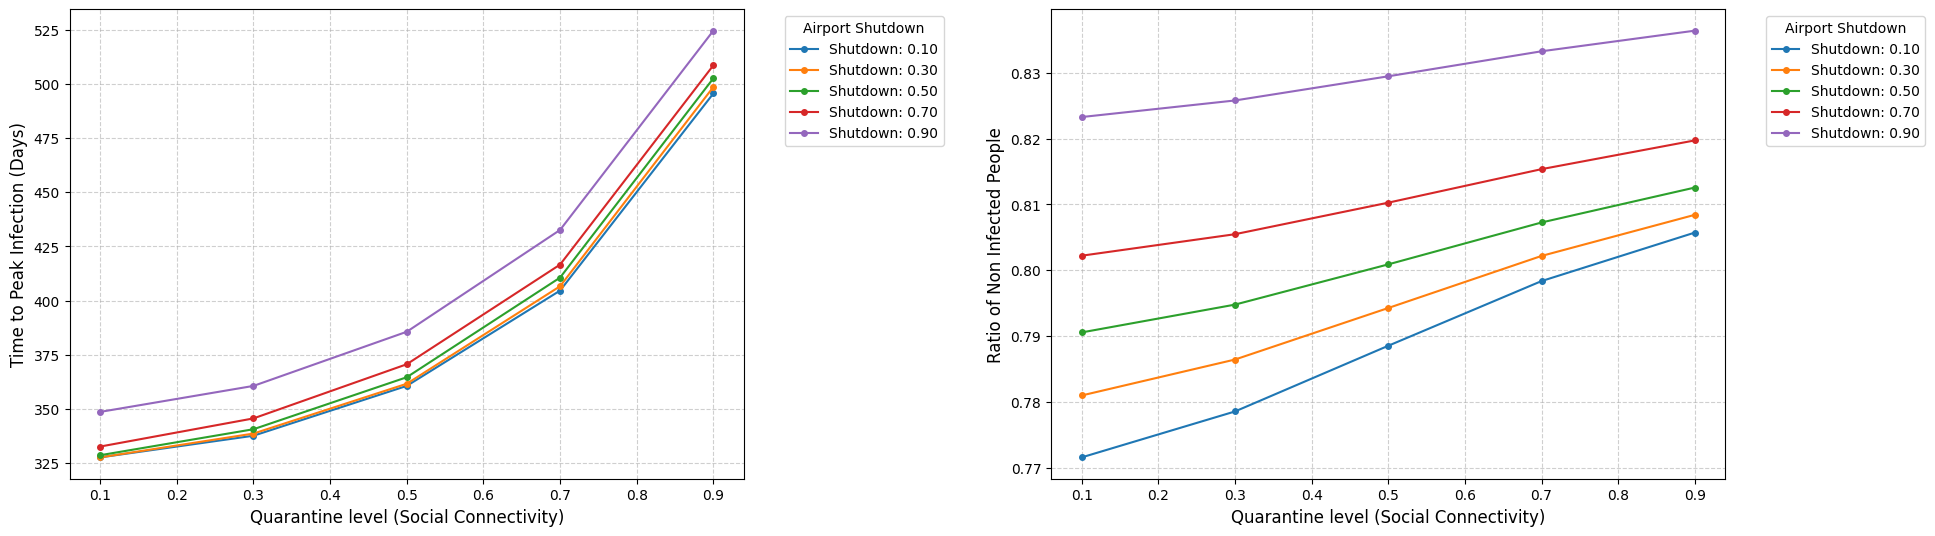

In [14]:
local_vs_global_quarantine_2d(population, init_state, C, beta, mu, 
                               t_end=t_end, 
                               quarantine_range=np.linspace(0.1, 0.9, 5),
                               top_nodes_under_quarantine=5,
                               social_connectivity_range=np.linspace(0.1, 0.9, 5))

Location : RO ; Population : 84595592.727


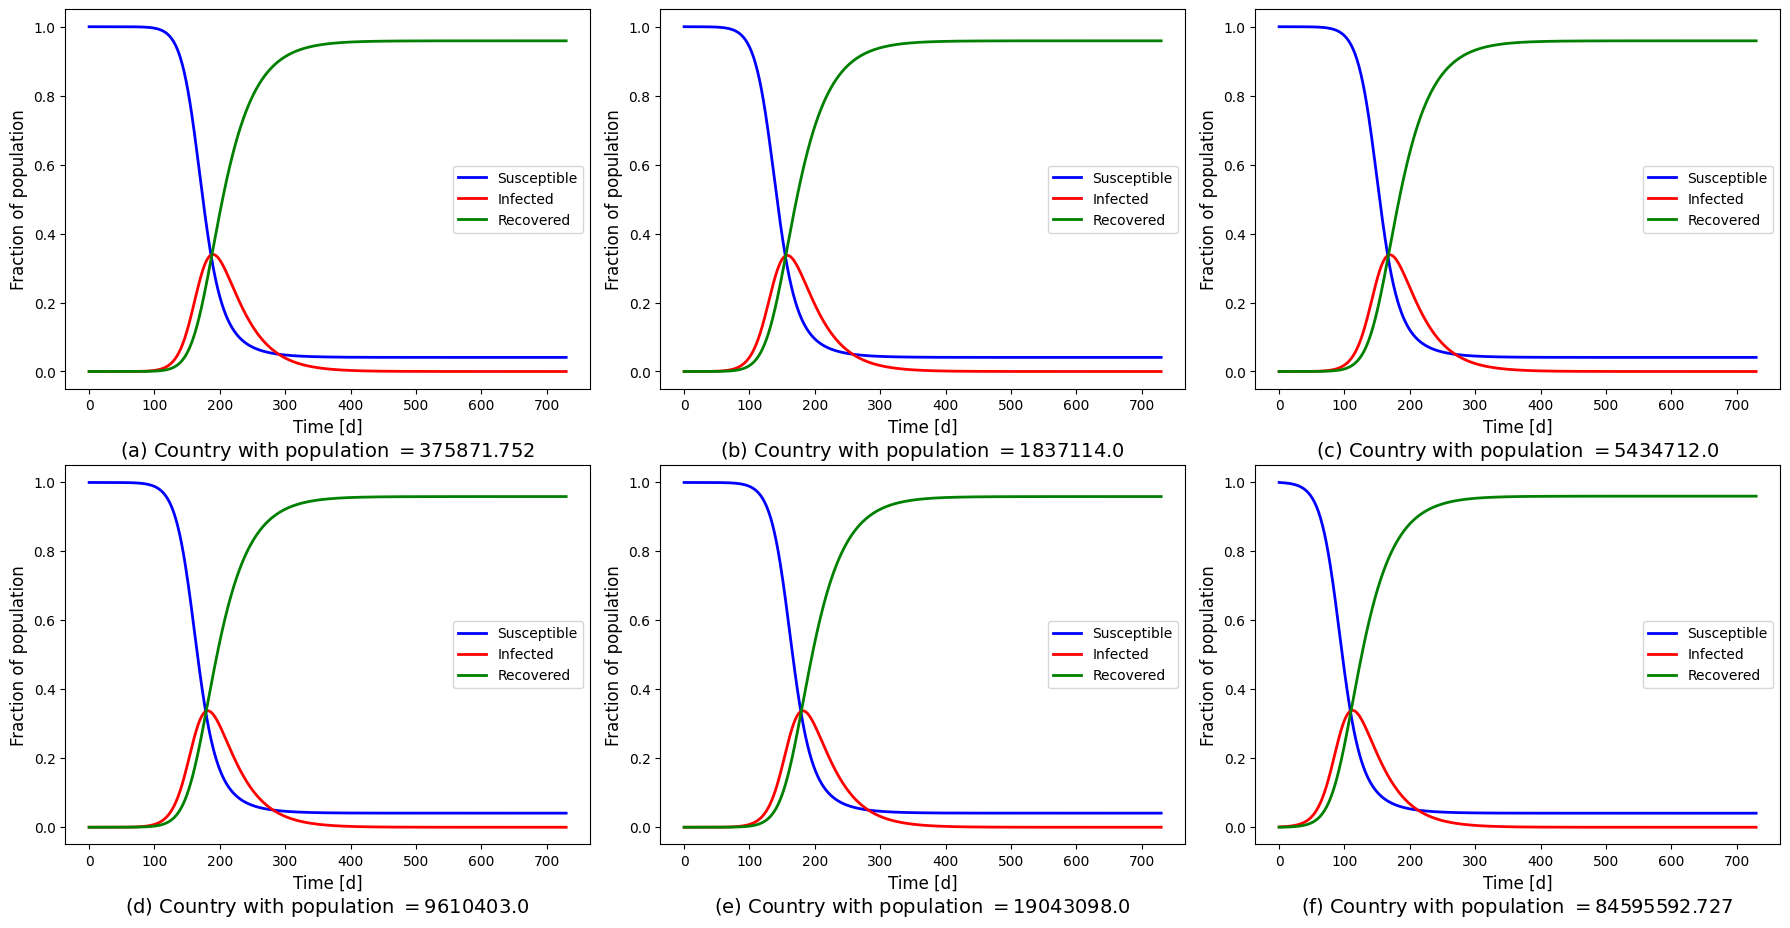

In [15]:
# Seed 0.1% infection in the highest populated country; rest fully susceptible
S0 = population
S0[np.argmax(population)] = 0.999 * np.max(population)

I0 = np.zeros_like(population)
I0[np.argmax(population)] = 0.001 * np.max(population)
init_state = np.concatenate([S0, I0, R0])

print("Location :", valid_countries[np.argmax(population)], "; Population :", np.max(population))

social_connectivity_comp(population, init_state, C,
                          t_end=t_end, infection_rate=beta, recovery_rate=mu)

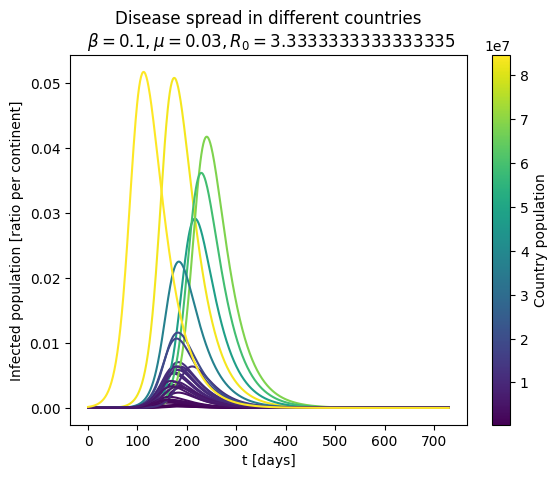

In [16]:
simple_plot(population, init_state, C,
                          t_end=t_end, infection_rate=beta, recovery_rate=mu)

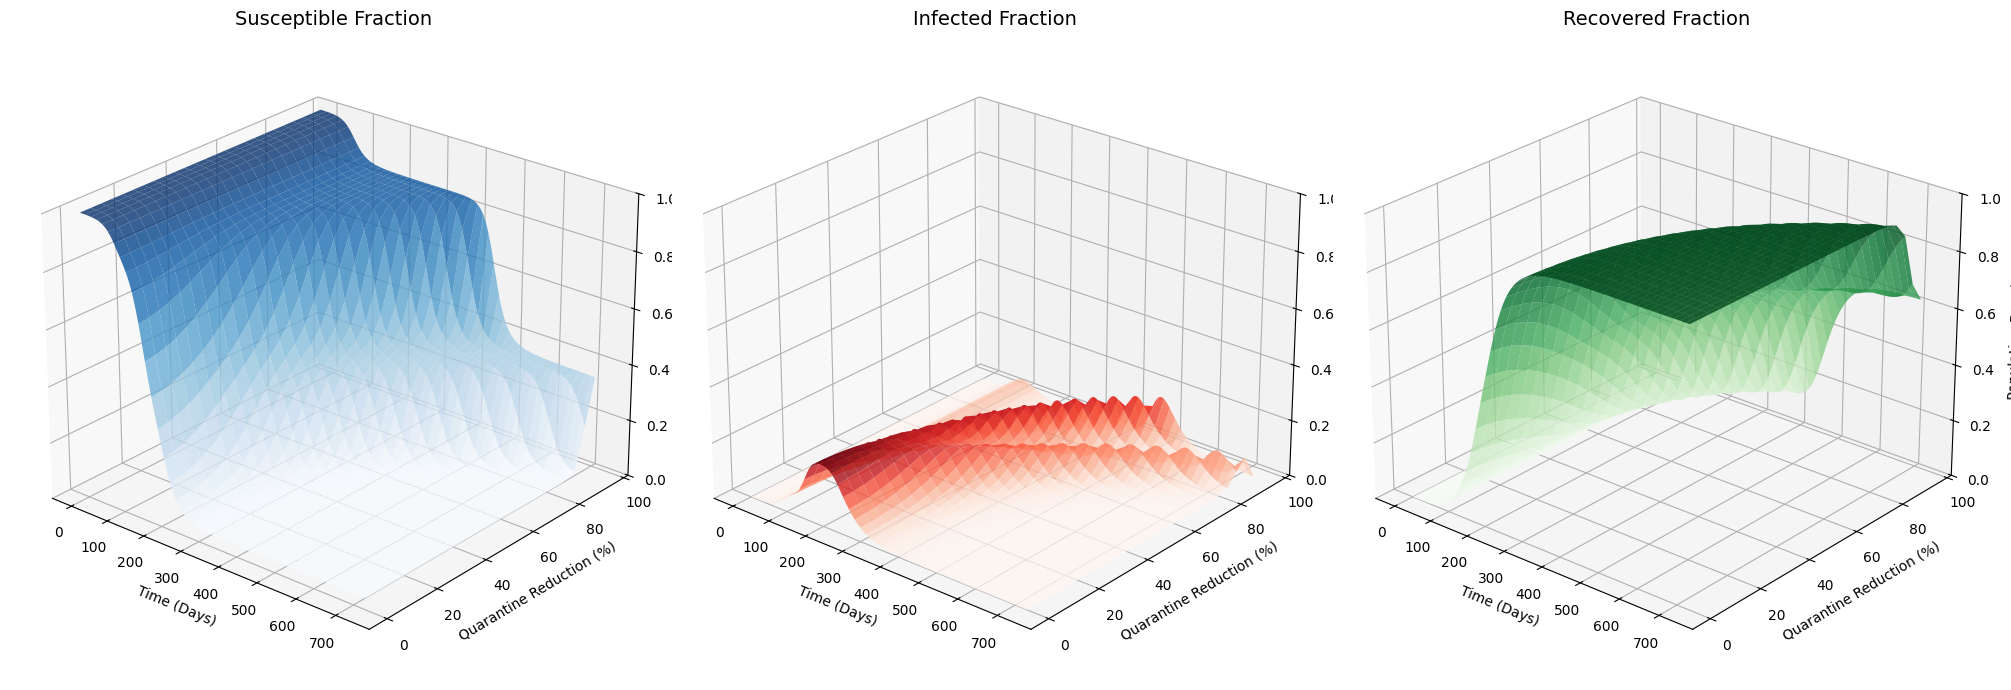

In [17]:
quarantine_plotter_3d(population, init_state, C,
                        infection_rate=beta, recovery_rate=mu, t_end=t_end)

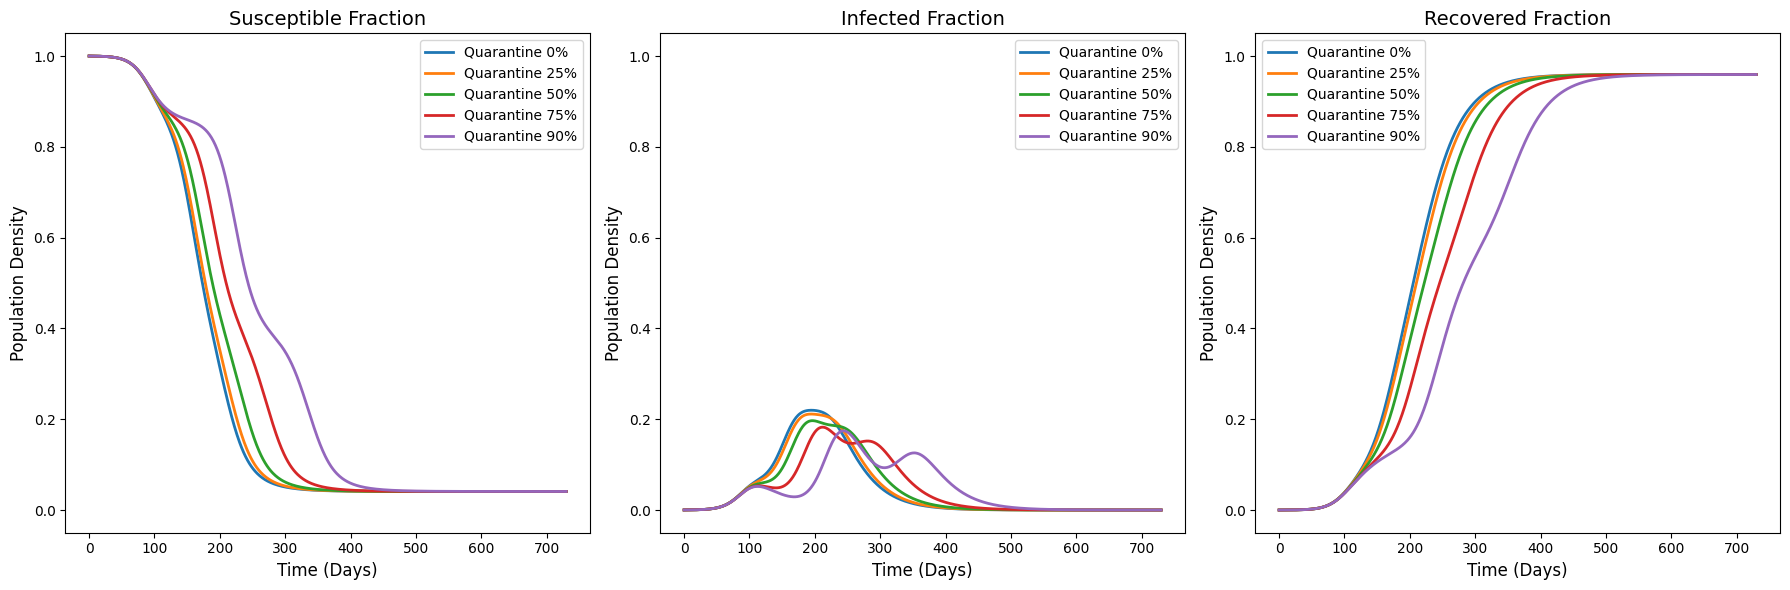

In [18]:
quarantine_plotter_2d(population, init_state, C,
                        infection_rate=beta, recovery_rate=mu, t_end=t_end)

Running 25 simulations. Please wait...


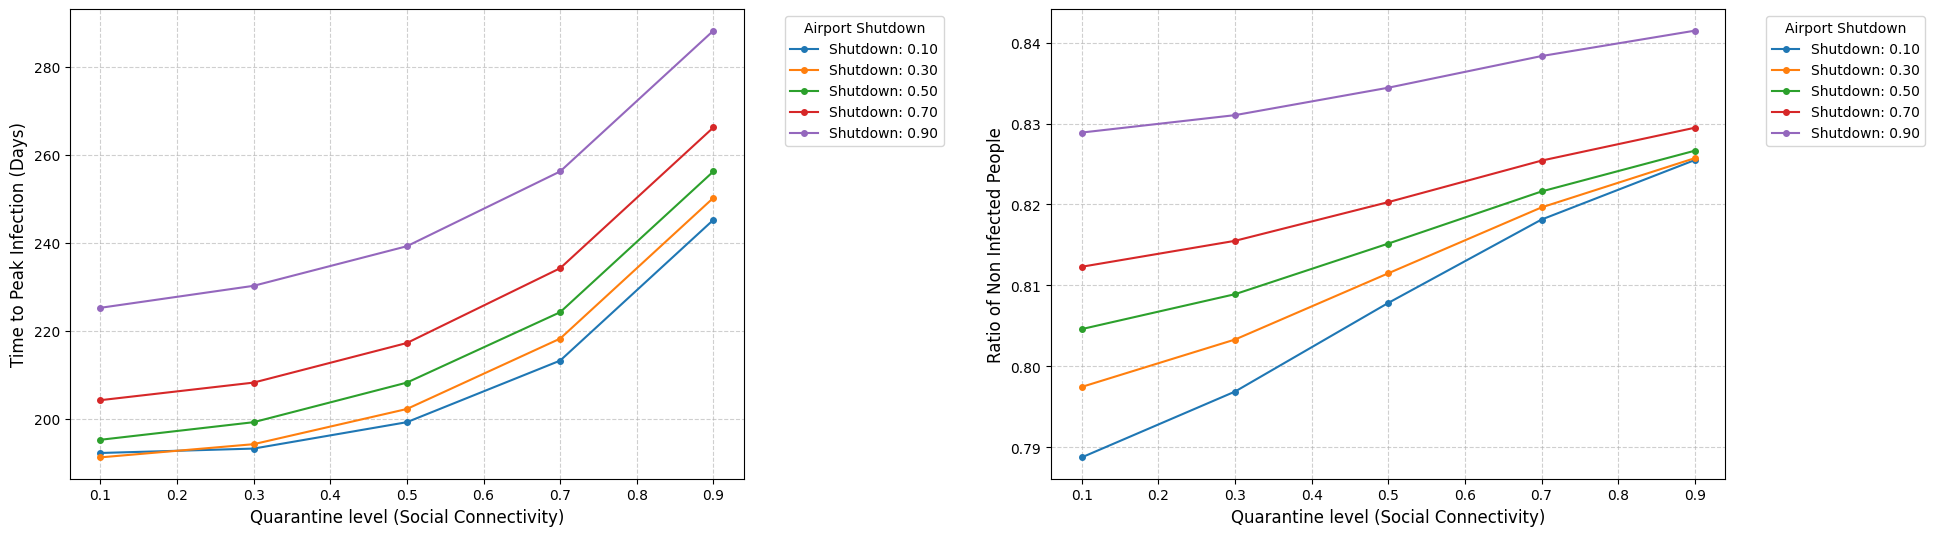

In [19]:
local_vs_global_quarantine_2d(population, init_state, C, beta, mu, 
                               t_end=t_end, 
                               quarantine_range=np.linspace(0.1, 0.9, 5),
                               top_nodes_under_quarantine=5,
                               social_connectivity_range=np.linspace(0.1, 0.9, 5))